# Optimalisasi Stok Barang UMKM

## Pendahuluan
Pada notebook ini, kita akan membangun model prediksi untuk mengoptimalkan stok barang UMKM menggunakan metode machine learning. Model ini akan membantu UMKM dalam merencanakan pembelian barang dengan lebih efisien.

## Langkah 1: Memuat Dataset
Pada langkah ini, kita akan memuat dataset yang berisi data historis mengenai penjualan dan tingkat stok barang. Data ini akan digunakan untuk melatih model prediksi optimalisasi stok barang berbasis AI.

In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('9_stok_barang.xlsx')
dummy_df


,Year,Month,Sales,Stock Level
0,2023,7,43.283193,38.573065
1,2023,4,14.711952,28.468646
2,2022,3,79.081087,46.839781
3,2022,1,47.485399,37.783817
4,2023,12,83.996190,39.159242
...,...,...,...,...
295,2021,12,55.800150,26.478324
296,2022,9,43.235269,44.821079
297,2023,3,93.963238,35.256757
298,2021,2,84.475569,31.300163


## Langkah 2: Visualisasi Data
Setelah memuat dataset, kita akan melihat hubungan antara penjualan dan tingkat stok barang. Ini akan membantu kita memahami pola yang ada dalam data.

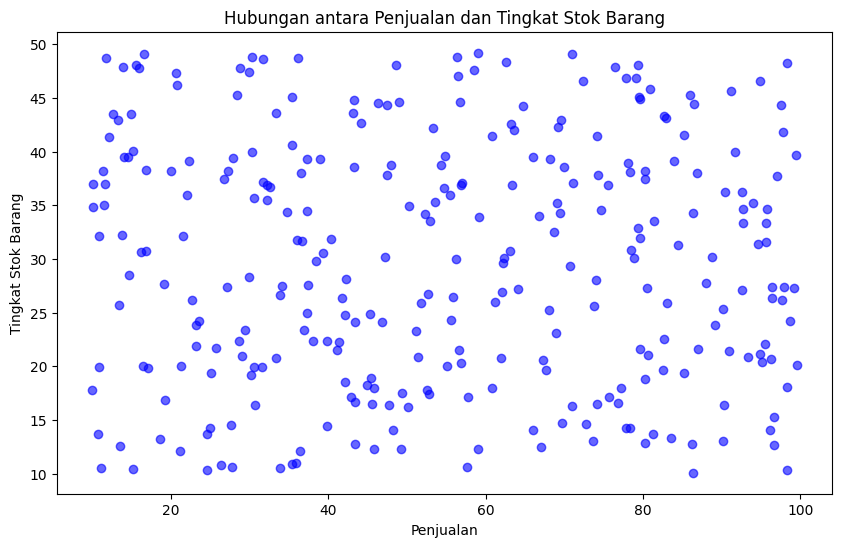

In [ ]:

import matplotlib.pyplot as plt

# Plotting the relationship between Sales and Stock Level
plt.figure(figsize=(10, 6))
plt.scatter(dummy_df["Sales"], dummy_df["Stock Level"], color='blue', alpha=0.6)
plt.title("Hubungan antara Penjualan dan Tingkat Stok Barang")
plt.xlabel("Penjualan")
plt.ylabel("Tingkat Stok Barang")
plt.show()


## Langkah 3: Preprocessing Data
Pada langkah ini, kita akan memproses data penjualan dan stok untuk mengubahnya menjadi format yang dapat dipahami oleh model machine learning, serta memilih fitur yang relevan.

In [ ]:

# Selecting features (X) and target variable (y)
X = dummy_df[["Sales"]]
y = dummy_df["Stock Level"]

# Show the first few rows of the data
X.head(), y.head()


(       Sales
 0  43.283193
 1  14.711952
 2  79.081087
 3  47.485399
 4  83.996190,
 0    38.573065
 1    28.468646
 2    46.839781
 3    37.783817
 4    39.159242
 Name: Stock Level, dtype: float64)

## Langkah 4: Pembagian Data Train dan Test
Setelah preprocessing, kita akan membagi dataset menjadi dua bagian: satu untuk pelatihan model (train) dan satu lagi untuk menguji akurasi model (test). Pembagian ini penting untuk mengevaluasi kinerja model.

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shape of the train and test sets
X_train.shape, X_test.shape


((210, 1), (90, 1))

## Langkah 5: Melatih Model
Pada langkah ini, kita akan melatih model menggunakan algoritma Linear Regression untuk memprediksi tingkat stok barang berdasarkan penjualan. Algoritma ini cocok untuk masalah regresi di mana kita memprediksi nilai kontinu.

In [ ]:

from sklearn.linear_model import LinearRegression

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Check the accuracy on the training data
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

train_score, test_score


(0.0018001429137676217, -0.04052012642616809)

## Langkah 6: Evaluasi Model
Setelah melatih model, kita akan mengevaluasi kinerjanya menggunakan metrik seperti Mean Squared Error (MSE) dan R-squared (R²) untuk mengetahui seberapa baik model dalam memprediksi stok barang yang optimal.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2


(117.17037183904262, -0.04052012642616809)

## Langkah 7: Prediksi
Setelah model dilatih, kita dapat menggunakannya untuk memprediksi tingkat stok barang berdasarkan data penjualan baru. Prediksi ini dapat membantu UMKM dalam merencanakan pembelian barang yang lebih efisien.

In [ ]:

# Example prediction for a new sales data (e.g., sales = 80)
new_sales = np.array([[80]])

# Predict stock level for the new sales
stock_prediction = model.predict(new_sales)
stock_prediction


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([29.80287397])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
